In [8]:
import pandas as pd

df = pd.read_csv("C:/Users/Gouri/OneDrive/Documents/stock-analysis/data/raw/AAPL.csv", index_col=0, parse_dates=True)
print(df.shape)
print(df.head())

(1006, 5)
                Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
2020-01-03  71.630646  72.389265  71.406674  71.563213  146322800
2020-01-06  72.201424  72.239958  70.503561  70.754028  118387200
2020-01-07  71.861855  72.466338  71.642697  72.211056  108872000
2020-01-08  73.017838  73.318877  71.565621  71.565621  132079200


In [9]:
print(df.dtypes)
print(df.isnull().sum())

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [10]:
print(df.describe())

             Close         High          Low         Open        Volume
count  1006.000000  1006.000000  1006.000000  1006.000000  1.006000e+03
mean    137.831006   139.310700   136.203195   137.701085  9.895373e+07
std      33.327124    33.447106    33.188109    33.320865  5.439610e+07
min      54.163704    55.160702    51.324800    55.059313  2.404830e+07
25%     120.286180   121.526050   118.754690   120.391648  6.407675e+07
50%     142.684906   144.257313   141.024898   142.534817  8.467540e+07
75%     163.044827   165.318781   161.792378   163.312399  1.155069e+08
max     195.892639   197.385733   194.795046   195.803650  4.265100e+08


In [11]:
import matplotlib.pyplot as plt

tickers = ["AAPL", "GOOGL", "MSFT", "TSLA"]
base = "C:/Users/Gouri/OneDrive/Documents/stock-analysis/data/raw/"

stocks = {}
for ticker in tickers:
    stocks[ticker] = pd.read_csv(base + ticker + ".csv", index_col=0, parse_dates=True)

print("All loaded!")

All loaded!


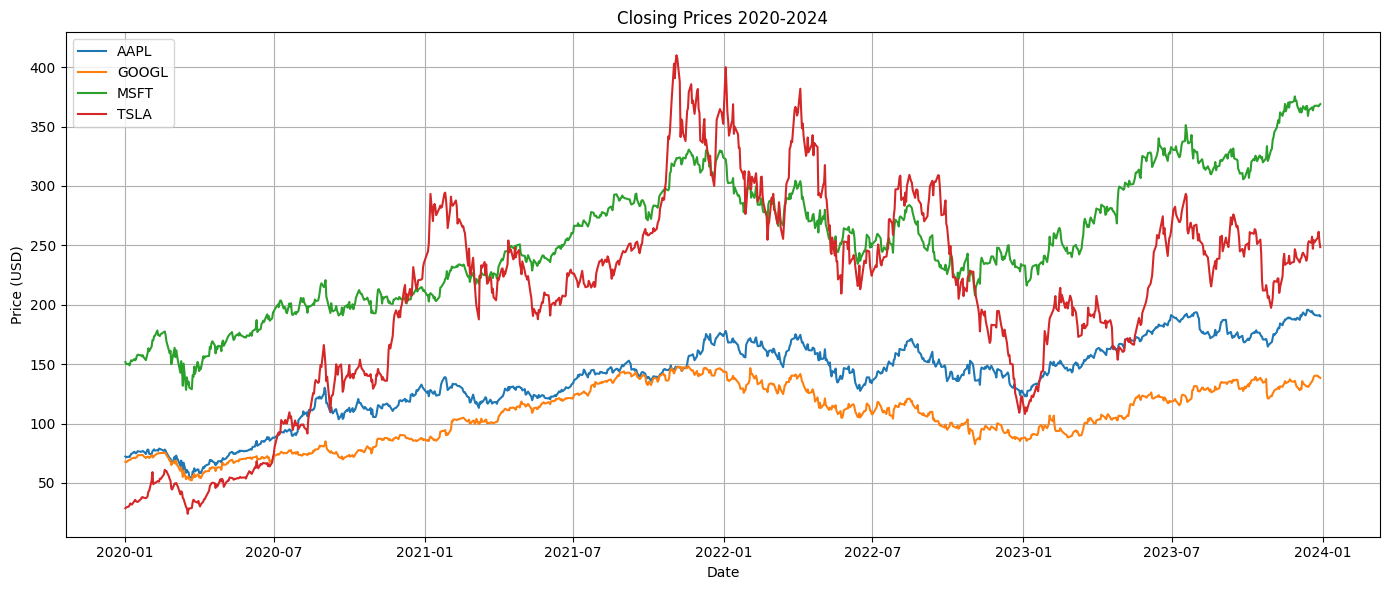

In [12]:
plt.figure(figsize=(14, 6))
for ticker in tickers:
    plt.plot(stocks[ticker].index, stocks[ticker]["Close"], label=ticker)

plt.title("Closing Prices 2020-2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

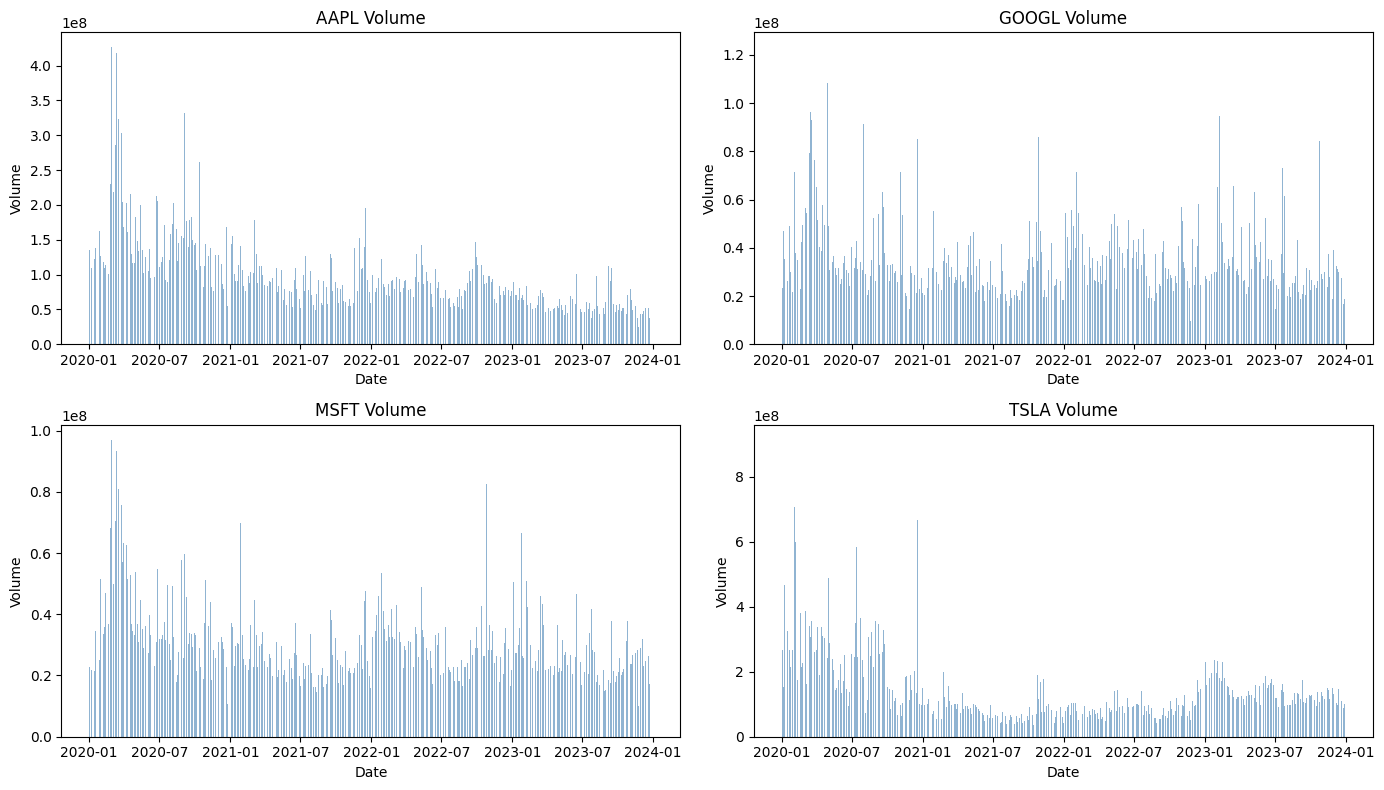

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    axes[i].bar(stocks[ticker].index, stocks[ticker]["Volume"], color="steelblue", alpha=0.6)
    axes[i].set_title(f"{ticker} Volume")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Volume")

plt.tight_layout()
plt.show()

In [14]:
for ticker in tickers:
    print(f"{ticker} nulls: {stocks[ticker].isnull().sum().sum()}")

AAPL nulls: 0
GOOGL nulls: 0
MSFT nulls: 0
TSLA nulls: 0


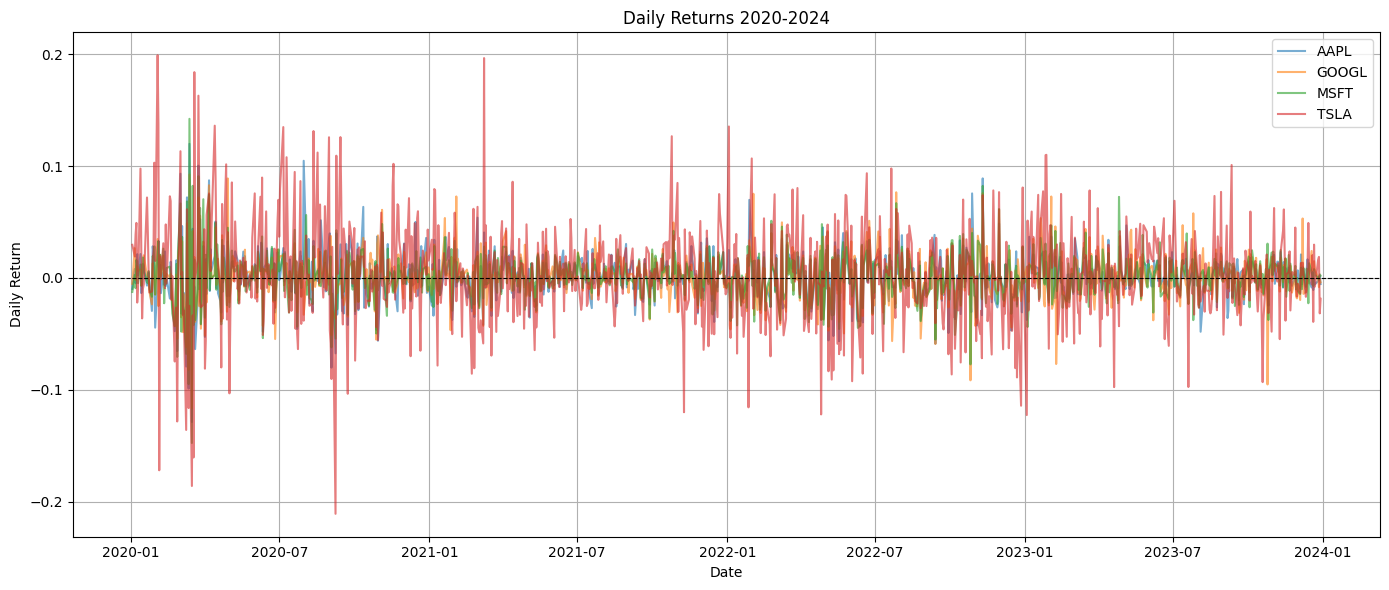

In [15]:
plt.figure(figsize=(14, 6))
for ticker in tickers:
    daily_return = stocks[ticker]["Close"].pct_change()
    plt.plot(stocks[ticker].index, daily_return, label=ticker, alpha=0.6)

plt.title("Daily Returns 2020-2024")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

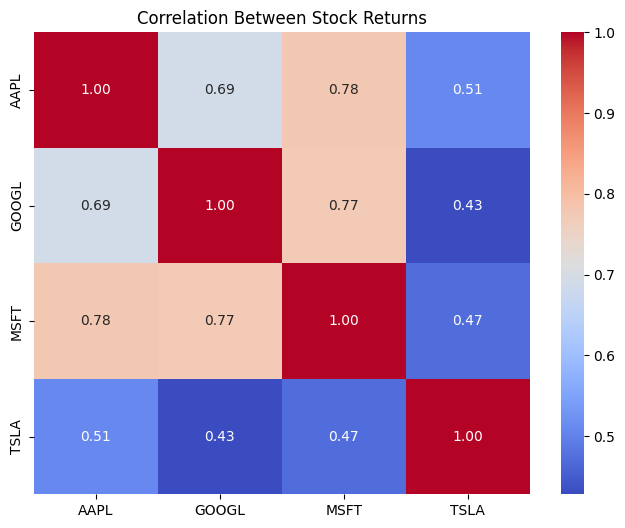

In [16]:
import seaborn as sns

returns = pd.DataFrame()
for ticker in tickers:
    returns[ticker] = stocks[ticker]["Close"].pct_change()

plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Stock Returns")
plt.show()